# Riskfolio Example 1

In [32]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
# start = '2016-01-01'
# end = '2025-08-08'

# # Tickers of assets
# assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MMC', 'JPM',
#           'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
#           'DE', 'MSFT', 'HPQ', 'SEE', 'VZ', 'CNP', 'NI', 'T', 'BA']
# assets.sort()

# # Downloading data
# data = yf.download(assets, start = start, end = end, auto_adjust=False)
# data = data.loc[:,('Adj Close', slice(None))]
# data.columns = assets

In [66]:
# Date range
start = '2020-01-01'
end = '2025-08-08'

# Tickers of assets 
assets = ['AVEM', 'AVES', 'XMMO', 'IEF', 'ESGD', 'BYLD', 'ISCF', 'HYEM', 'VWOB', 'VNQI', 'VNQ', 'SNPE'] # , 'AGEPX', 'SWSSX', 'SWVXX' mutual funds 
assets.sort()
raw_data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = raw_data .loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  12 of 12 completed


In [54]:
# icsf= yf.Ticker("ISCF")
# icsf.info

In [55]:
# get etf categories 

# categories = {}

# for asset in assets:
#     ticker = yf.Ticker(asset)
#     info = ticker.info
#     category = info.get('category', 'Unknown')
#     categories[asset] = category
# categories

In [69]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
Date,,,,,,,,,,,,
2021-10-01,0.0775%,0.0657%,0.3505%,0.2297%,-0.0389%,0.4082%,0.2031%,1.1591%,1.4148%,-0.1421%,-0.0718%,1.8541%
2021-10-04,-1.3786%,-1.9211%,-0.2266%,-1.0692%,-0.5197%,-0.1211%,-1.4109%,-1.1458%,0.0194%,-0.0178%,-0.4873%,-1.0619%
2021-10-05,0.7853%,1.1416%,-0.0398%,0.6819%,-0.1741%,-0.3118%,0.5141%,0.8693%,-0.6877%,-0.3202%,0.1805%,0.4364%
2021-10-06,-0.6857%,-1.0225%,-0.0399%,-0.6262%,-0.4361%,0.0261%,-0.5806%,0.6007%,0.9558%,-0.4818%,-0.2316%,-0.5049%
2021-10-07,1.5691%,1.3976%,-0.2791%,0.8616%,0.0438%,-0.3995%,0.6674%,0.9086%,0.2705%,0.8248%,0.1160%,1.6405%


## Estimating Mean Variance Portfolio

In [70]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be variance
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
weights,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,84.3573%,0.0000%,0.0000%,0.0000%,15.6426%


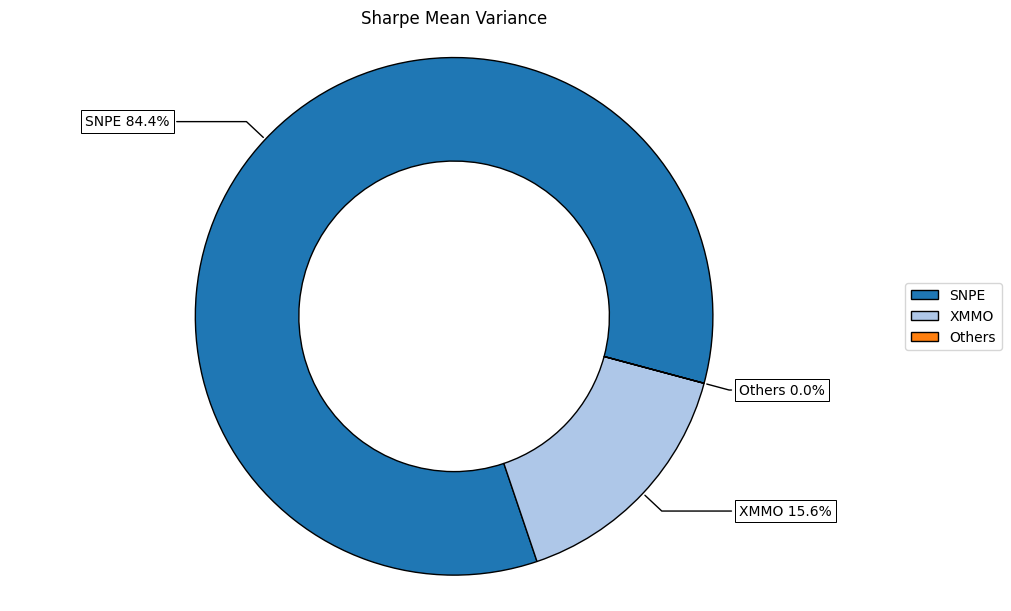

In [71]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w, title='Sharpe Mean Variance', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [72]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
0,0.0000%,0.0000%,92.6979%,0.0000%,7.3021%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
1,0.0000%,0.0000%,84.9507%,0.0000%,9.0391%,0.0000%,0.0000%,4.6899%,0.0000%,0.0000%,0.0000%,1.3204%
2,0.0000%,0.0000%,82.4362%,0.0000%,6.9198%,0.0000%,0.0000%,8.6285%,0.0000%,0.0000%,0.0000%,2.0154%
3,0.0000%,0.0000%,80.3057%,0.0000%,5.0877%,0.0000%,0.0000%,11.9977%,0.0000%,0.0000%,0.0000%,2.6088%
4,0.0000%,0.0000%,78.3692%,0.0000%,3.4503%,0.0000%,0.0000%,15.0357%,0.0000%,0.0000%,0.0000%,3.1448%


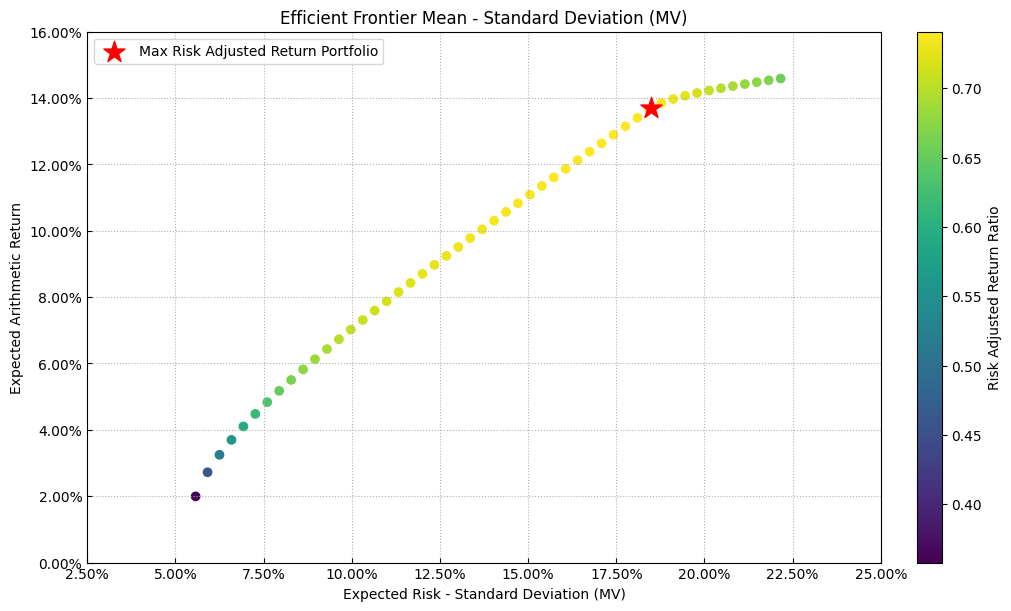

In [73]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=rm,
                      rf=rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

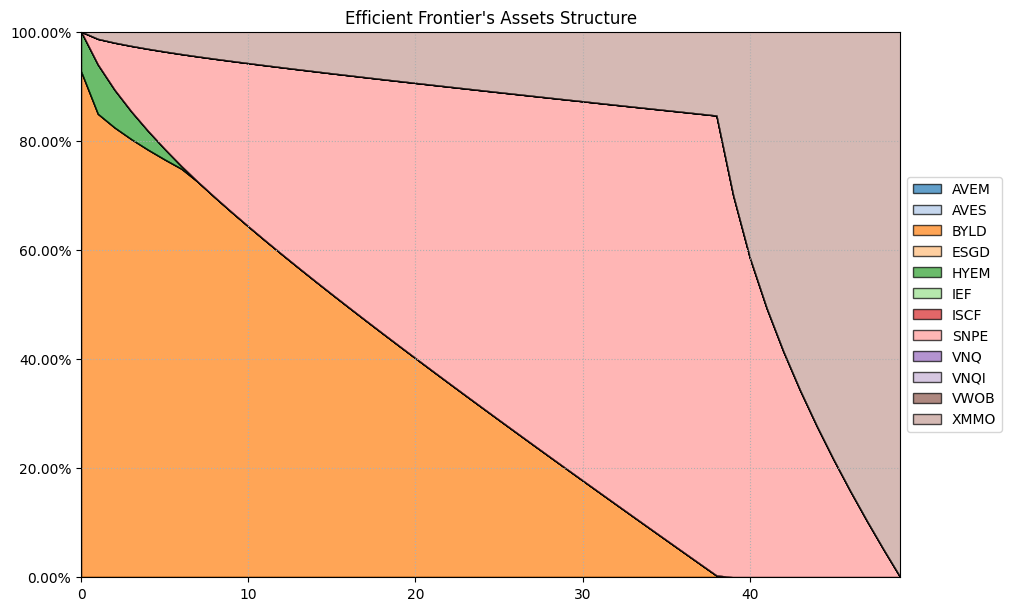

In [74]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

In [75]:
rm = 'CVaR' # Risk measure
obj= 'Sharpe'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
weights,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,94.7756%,0.0000%,0.0000%,0.0000%,5.2244%


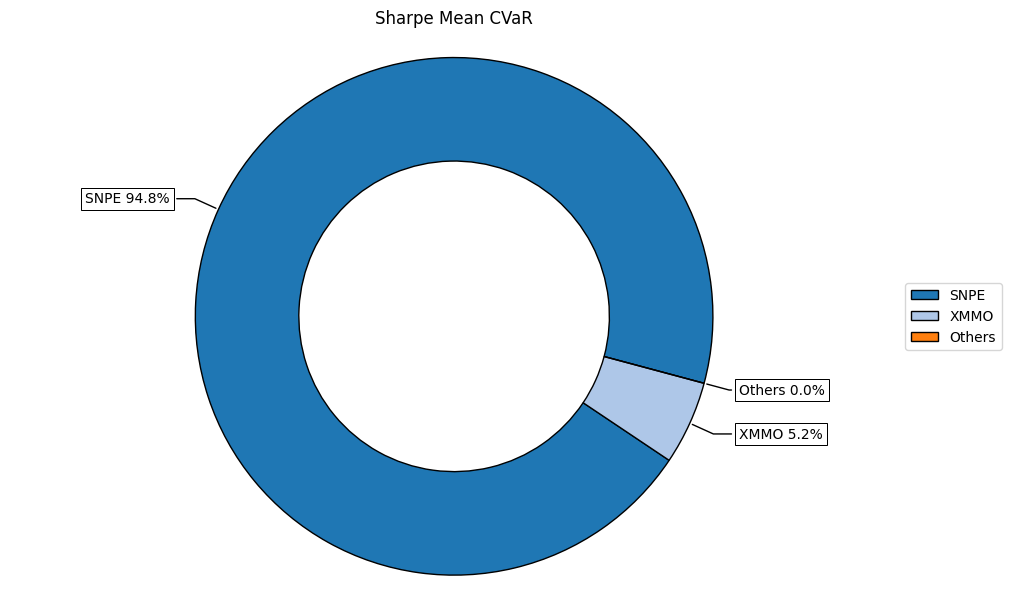

In [76]:
ax = rp.plot_pie(w=w, title='Sharpe Mean CVaR', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [15]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AVEM,AVES,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VNQ,VNQI,VWOB,XMMO
0,0.0000%,0.0000%,85.8863%,0.0000%,14.1137%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%
1,0.0000%,0.0000%,64.7604%,0.0000%,31.1064%,0.0000%,0.0000%,2.3022%,0.0000%,0.0000%,0.0000%,1.8310%
2,0.0000%,0.0000%,58.0281%,0.0000%,33.2493%,0.0000%,0.0000%,3.9673%,0.0000%,0.0000%,0.0000%,4.7553%
3,0.0000%,0.0000%,50.2341%,0.0000%,37.2003%,0.0000%,0.0000%,7.1181%,0.0000%,0.0000%,0.0000%,5.4475%
4,0.0000%,0.0000%,42.6705%,0.0000%,41.9673%,0.0000%,0.0000%,6.8665%,0.0000%,0.0000%,0.0000%,8.4957%


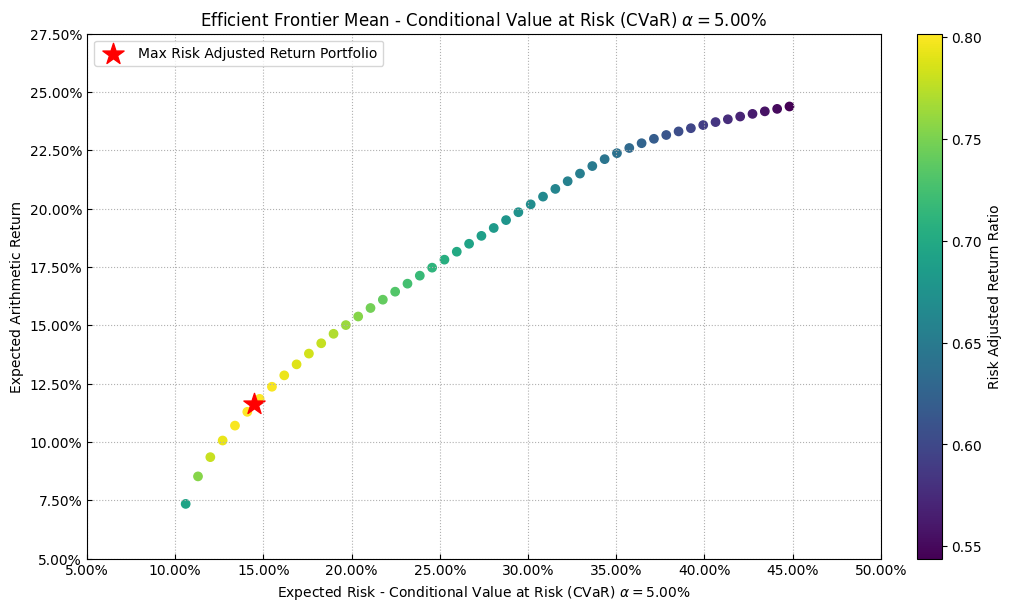

In [16]:
label = 'Max Risk Adjusted Return Portfolio' # Title of point

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=rm,
                      rf=rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

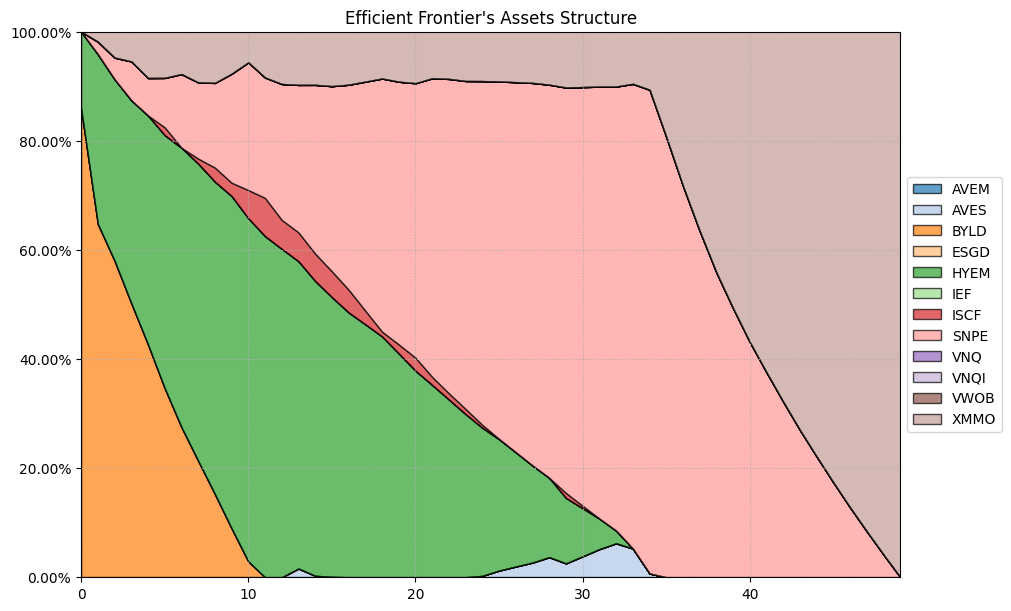

In [17]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

In [18]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model, rm=i, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms

In [19]:
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
AVEM,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
AVES,0.00%,1.43%,0.00%,0.38%,0.00%,0.00%,3.72%,7.02%,0.00%,0.00%,0.00%,0.00%,0.21%
BYLD,41.21%,33.30%,39.96%,31.93%,40.59%,28.44%,86.21%,40.36%,68.29%,41.38%,59.92%,42.79%,62.81%
ESGD,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
HYEM,44.16%,47.35%,44.32%,49.10%,43.92%,52.04%,0.00%,0.00%,31.71%,38.15%,28.50%,36.46%,33.21%
IEF,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,41.00%,0.00%,0.00%,0.00%,0.00%,0.00%
ISCF,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
SNPE,11.77%,17.93%,13.63%,18.59%,13.03%,11.18%,3.63%,0.00%,0.00%,20.47%,0.00%,18.86%,0.00%
VNQ,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
VNQI,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


<Axes: >

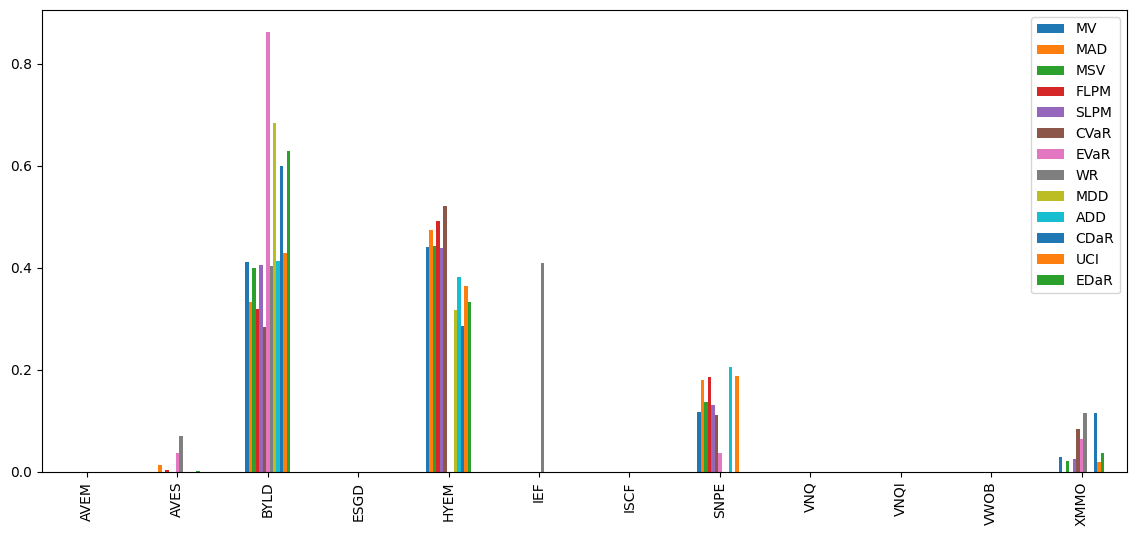

In [20]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(14)
fig.set_figheight(6)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot.bar(ax=ax)